# Home Credit Default Risk Predictor
## Feature Engineering

In this notebook, we create **domain-driven features** from existing columns to improve model predictive power.

| # | New Feature | Formula | Business Meaning |
|---|---|---|---|
| 1 | `CREDIT_INCOME_RATIO` | `AMT_CREDIT / AMT_INCOME_TOTAL` | How large is the loan compared to income? |
| 2 | `ANNUITY_INCOME_RATIO` | `AMT_ANNUITY / AMT_INCOME_TOTAL` | How much income is consumed by EMI payments? |
| 3 | `CREDIT_GOODS_RATIO` | `AMT_CREDIT / AMT_GOODS_PRICE` | Loan amount relative to item value |
| 4 | `INCOME_PER_CHILD` | `AMT_INCOME_TOTAL / (CNT_CHILDREN + 1)` | Financial burden due to dependents |
| 5 | `EXT_SOURCE_MEAN` | `mean(EXT_SOURCE_1, EXT_SOURCE_2, EXT_SOURCE_3)` | Average external credit score — composite creditworthiness |
| 6 | `CREDIT_TERM` | `AMT_CREDIT / AMT_ANNUITY` | Estimated loan duration in payment periods |
| 7 | `EMPLOYED_TO_AGE_RATIO` | `YEARS_EMPLOYED / AGE` | Job stability relative to age |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Load preprocessed data from the previous step
train = pd.read_csv('train_preprocessed.csv')
test = pd.read_csv('test_preprocessed.csv')

print(f'Training Data Shape : {train.shape}')
print(f'Test Data Shape     : {test.shape}')

Training Data Shape : (307511, 59)
Test Data Shape     : (48744, 58)


---
## 1. Create Engineered Features

### Existing Ratio Features

All ratio-based features capture the relative magnitude between two financial quantities, which is more informative than the raw amounts alone.

### 1.1 Credit-to-Income Ratio

**Formula:** `AMT_CREDIT / AMT_INCOME_TOTAL`

**Business meaning:** Measures how large the loan amount is compared to the applicant's annual income. A higher ratio indicates greater financial strain — the applicant is borrowing a multiple of their income.

In [3]:
train['CREDIT_INCOME_RATIO'] = train['AMT_CREDIT'] / train['AMT_INCOME_TOTAL']
test['CREDIT_INCOME_RATIO'] = test['AMT_CREDIT'] / test['AMT_INCOME_TOTAL']

print('CREDIT_INCOME_RATIO — Sample values (train):')
print(train[['AMT_CREDIT', 'AMT_INCOME_TOTAL', 'CREDIT_INCOME_RATIO']].head(10).to_string(index=False))

CREDIT_INCOME_RATIO — Sample values (train):
 AMT_CREDIT  AMT_INCOME_TOTAL  CREDIT_INCOME_RATIO
   406597.5          202500.0             2.007889
  1293502.5          270000.0             4.790750
   135000.0           67500.0             2.000000
   312682.5          135000.0             2.316167
   513000.0          121500.0             4.222222
   490495.5           99000.0             4.954500
  1560726.0          171000.0             9.127053
  1530000.0          360000.0             4.250000
  1019610.0          112500.0             9.063200
   405000.0          135000.0             3.000000


### 1.2 Annuity-to-Income Ratio

**Formula:** `AMT_ANNUITY / AMT_INCOME_TOTAL`

**Business meaning:** Measures the proportion of annual income consumed by EMI (loan instalment) payments. A higher ratio signals that a significant portion of income goes towards debt servicing, leaving less for other expenses — a key indicator of repayment stress.

In [4]:
train['ANNUITY_INCOME_RATIO'] = train['AMT_ANNUITY'] / train['AMT_INCOME_TOTAL']
test['ANNUITY_INCOME_RATIO'] = test['AMT_ANNUITY'] / test['AMT_INCOME_TOTAL']

print('ANNUITY_INCOME_RATIO — Sample values (train):')
print(train[['AMT_ANNUITY', 'AMT_INCOME_TOTAL', 'ANNUITY_INCOME_RATIO']].head(10).to_string(index=False))

ANNUITY_INCOME_RATIO — Sample values (train):
 AMT_ANNUITY  AMT_INCOME_TOTAL  ANNUITY_INCOME_RATIO
     24700.5          202500.0              0.121978
     35698.5          270000.0              0.132217
      6750.0           67500.0              0.100000
     29686.5          135000.0              0.219900
     21865.5          121500.0              0.179963
     27517.5           99000.0              0.277955
     41301.0          171000.0              0.241526
     42075.0          360000.0              0.116875
     33826.5          112500.0              0.300680
     20250.0          135000.0              0.150000


### 1.3 Credit-to-Goods Ratio

**Formula:** `AMT_CREDIT / AMT_GOODS_PRICE`

**Business meaning:** Compares the loan amount to the price of the goods being purchased. A ratio > 1 means the loan exceeds the item value (includes fees/insurance), while a ratio ≈ 1 means the loan exactly covers the item. Lower ratios suggest a down payment was made.

In [5]:
train['CREDIT_GOODS_RATIO'] = train['AMT_CREDIT'] / train['AMT_GOODS_PRICE']
test['CREDIT_GOODS_RATIO'] = test['AMT_CREDIT'] / test['AMT_GOODS_PRICE']

print('CREDIT_GOODS_RATIO — Sample values (train):')
print(train[['AMT_CREDIT', 'AMT_GOODS_PRICE', 'CREDIT_GOODS_RATIO']].head(10).to_string(index=False))

CREDIT_GOODS_RATIO — Sample values (train):
 AMT_CREDIT  AMT_GOODS_PRICE  CREDIT_GOODS_RATIO
   406597.5         351000.0            1.158397
  1293502.5        1129500.0            1.145199
   135000.0         135000.0            1.000000
   312682.5         297000.0            1.052803
   513000.0         513000.0            1.000000
   490495.5         454500.0            1.079198
  1560726.0        1395000.0            1.118800
  1530000.0        1530000.0            1.000000
  1019610.0         913500.0            1.116158
   405000.0         405000.0            1.000000


### 1.4 Income Per Child

**Formula:** `AMT_INCOME_TOTAL / (CNT_CHILDREN + 1)`

**Business meaning:** Represents the income available per family member (including the applicant). Adding 1 to `CNT_CHILDREN` accounts for the applicant themselves and avoids division-by-zero for childless applicants. Lower values indicate greater financial burden due to dependents.

In [6]:
train['INCOME_PER_CHILD'] = train['AMT_INCOME_TOTAL'] / (train['CNT_CHILDREN'] + 1)
test['INCOME_PER_CHILD'] = test['AMT_INCOME_TOTAL'] / (test['CNT_CHILDREN'] + 1)

print('INCOME_PER_CHILD — Sample values (train):')
print(train[['AMT_INCOME_TOTAL', 'CNT_CHILDREN', 'INCOME_PER_CHILD']].head(10).to_string(index=False))

INCOME_PER_CHILD — Sample values (train):
 AMT_INCOME_TOTAL  CNT_CHILDREN  INCOME_PER_CHILD
         202500.0             0          202500.0
         270000.0             0          270000.0
          67500.0             0           67500.0
         135000.0             0          135000.0
         121500.0             0          121500.0
          99000.0             0           99000.0
         171000.0             1           85500.0
         360000.0             0          360000.0
         112500.0             0          112500.0
         135000.0             0          135000.0


---
### New Engineered Features (using the newly added columns)

### 1.5 External Source Mean

**Formula:** `mean(EXT_SOURCE_1, EXT_SOURCE_2, EXT_SOURCE_3)`

**Business meaning:** Each EXT_SOURCE is a normalized credit score from an external bureau (like Experian, Equifax, etc.). Averaging all three gives a composite creditworthiness score — more robust than any single source. This was historically the #1 most predictive feature in the Home Credit Kaggle competition.

In [7]:
ext_cols = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']

train['EXT_SOURCE_MEAN'] = train[ext_cols].mean(axis=1)
test['EXT_SOURCE_MEAN'] = test[ext_cols].mean(axis=1)

print('EXT_SOURCE_MEAN — Sample values (train):')
print(train[ext_cols + ['EXT_SOURCE_MEAN']].head(10).to_string(index=False))

EXT_SOURCE_MEAN — Sample values (train):
 EXT_SOURCE_1  EXT_SOURCE_2  EXT_SOURCE_3  EXT_SOURCE_MEAN
     0.083037      0.262949      0.139376         0.161787
     0.311267      0.622246      0.535276         0.489596
     0.505998      0.555912      0.729567         0.597159
     0.505998      0.650442      0.535276         0.563905
     0.505998      0.322738      0.535276         0.454671
     0.505998      0.354225      0.621226         0.493816
     0.774761      0.724000      0.492060         0.663607
     0.505998      0.714279      0.540654         0.586977
     0.587334      0.205747      0.751724         0.514935
     0.505998      0.746644      0.535276         0.595973


### 1.6 Credit Term

**Formula:** `AMT_CREDIT / AMT_ANNUITY`

**Business meaning:** Estimates the loan duration in payment periods (roughly months). A longer term means more time paying and more total interest. Very long or very short terms can signal different risk profiles.

In [8]:
train['CREDIT_TERM'] = train['AMT_CREDIT'] / train['AMT_ANNUITY']
test['CREDIT_TERM'] = test['AMT_CREDIT'] / test['AMT_ANNUITY']

print('CREDIT_TERM — Sample values (train):')
print(train[['AMT_CREDIT', 'AMT_ANNUITY', 'CREDIT_TERM']].head(10).to_string(index=False))

CREDIT_TERM — Sample values (train):
 AMT_CREDIT  AMT_ANNUITY  CREDIT_TERM
   406597.5      24700.5    16.461104
  1293502.5      35698.5    36.234085
   135000.0       6750.0    20.000000
   312682.5      29686.5    10.532818
   513000.0      21865.5    23.461618
   490495.5      27517.5    17.824857
  1560726.0      41301.0    37.789061
  1530000.0      42075.0    36.363636
  1019610.0      33826.5    30.142344
   405000.0      20250.0    20.000000


### 1.7 Employed-to-Age Ratio

**Formula:** `YEARS_EMPLOYED / AGE`

**Business meaning:** Measures job stability relative to age. A 40-year-old employed for 20 years (ratio=0.50) shows strong stability, while a 40-year-old employed for 1 year (ratio=0.025) suggests instability. It normalizes employment duration by age so it's comparable across different age groups.

In [9]:
train['EMPLOYED_TO_AGE_RATIO'] = train['YEARS_EMPLOYED'] / train['AGE']
test['EMPLOYED_TO_AGE_RATIO'] = test['YEARS_EMPLOYED'] / test['AGE']

print('EMPLOYED_TO_AGE_RATIO — Sample values (train):')
print(train[['YEARS_EMPLOYED', 'AGE', 'EMPLOYED_TO_AGE_RATIO']].head(10).to_string(index=False))

EMPLOYED_TO_AGE_RATIO — Sample values (train):
 YEARS_EMPLOYED   AGE  EMPLOYED_TO_AGE_RATIO
           1.74 25.90               0.067181
           3.25 45.90               0.070806
           0.62 52.15               0.011889
           8.32 52.03               0.159908
           8.32 54.57               0.152465
           4.35 46.38               0.093790
           8.57 37.72               0.227200
           1.23 51.61               0.023833
           0.00 55.03               0.000000
           5.53 39.61               0.139611


---
## 2. Validation

Let's verify that all new features were created correctly with no missing or infinite values.

In [10]:
new_features = ['CREDIT_INCOME_RATIO', 'ANNUITY_INCOME_RATIO', 'CREDIT_GOODS_RATIO', 'INCOME_PER_CHILD',
                'EXT_SOURCE_MEAN', 'CREDIT_TERM', 'EMPLOYED_TO_AGE_RATIO']

print('=== New Features — Missing & Infinite Value Check ===')
print(f'{"Feature":<25} {"Train NaN":>10} {"Train Inf":>10} {"Test NaN":>10} {"Test Inf":>10}')
print('-' * 70)

for feat in new_features:
    train_nan = train[feat].isna().sum()
    train_inf = np.isinf(train[feat]).sum()
    test_nan = test[feat].isna().sum()
    test_inf = np.isinf(test[feat]).sum()
    print(f'{feat:<25} {train_nan:>10} {train_inf:>10} {test_nan:>10} {test_inf:>10}')

print()
print('All features are clean!' if all(
    train[f].isna().sum() == 0 and np.isinf(train[f]).sum() == 0 and
    test[f].isna().sum() == 0 and np.isinf(test[f]).sum() == 0
    for f in new_features
) else 'Some features have NaN or Inf values — investigate!')

=== New Features — Missing & Infinite Value Check ===
Feature                    Train NaN  Train Inf   Test NaN   Test Inf
----------------------------------------------------------------------
CREDIT_INCOME_RATIO                0          0          0          0
ANNUITY_INCOME_RATIO               0          0          0          0
CREDIT_GOODS_RATIO                 0          0          0          0
INCOME_PER_CHILD                   0          0          0          0
EXT_SOURCE_MEAN                    0          0          0          0
CREDIT_TERM                        0          0          0          0
EMPLOYED_TO_AGE_RATIO              0          0          0          0

All features are clean!


### 2.1 Descriptive Statistics

In [11]:
print('=== Descriptive Statistics — Engineered Features (Training Data) ===')
train[new_features].describe().round(4)

=== Descriptive Statistics — Engineered Features (Training Data) ===


,CREDIT_INCOME_RATIO,ANNUITY_INCOME_RATIO,CREDIT_GOODS_RATIO,INCOME_PER_CHILD,EXT_SOURCE_MEAN,CREDIT_TERM,EMPLOYED_TO_AGE_RATIO
count,307511.0000,307511.0000,307511.0000,3.075110e+05,307511.0000,307511.0000,307511.0000
mean,3.9576,0.1809,1.1225,1.395079e+05,0.5115,21.6124,0.1286
std,2.6897,0.0946,0.1255,1.458110e+05,0.1081,7.8242,0.1351
min,0.0048,0.0002,0.1500,3.000000e+03,0.0237,6.3245,0.0000
25%,2.0187,0.1148,1.0000,7.875000e+04,0.4416,15.6145,0.0215
50%,3.2651,0.1628,1.1188,1.170000e+05,0.5216,20.0000,0.0886
75%,5.1599,0.2291,1.1980,1.800000e+05,0.5877,27.1000,0.1910
max,84.7368,1.8760,6.0000,5.850000e+07,0.8534,59.5604,0.7288


### 2.2 Distribution Plots

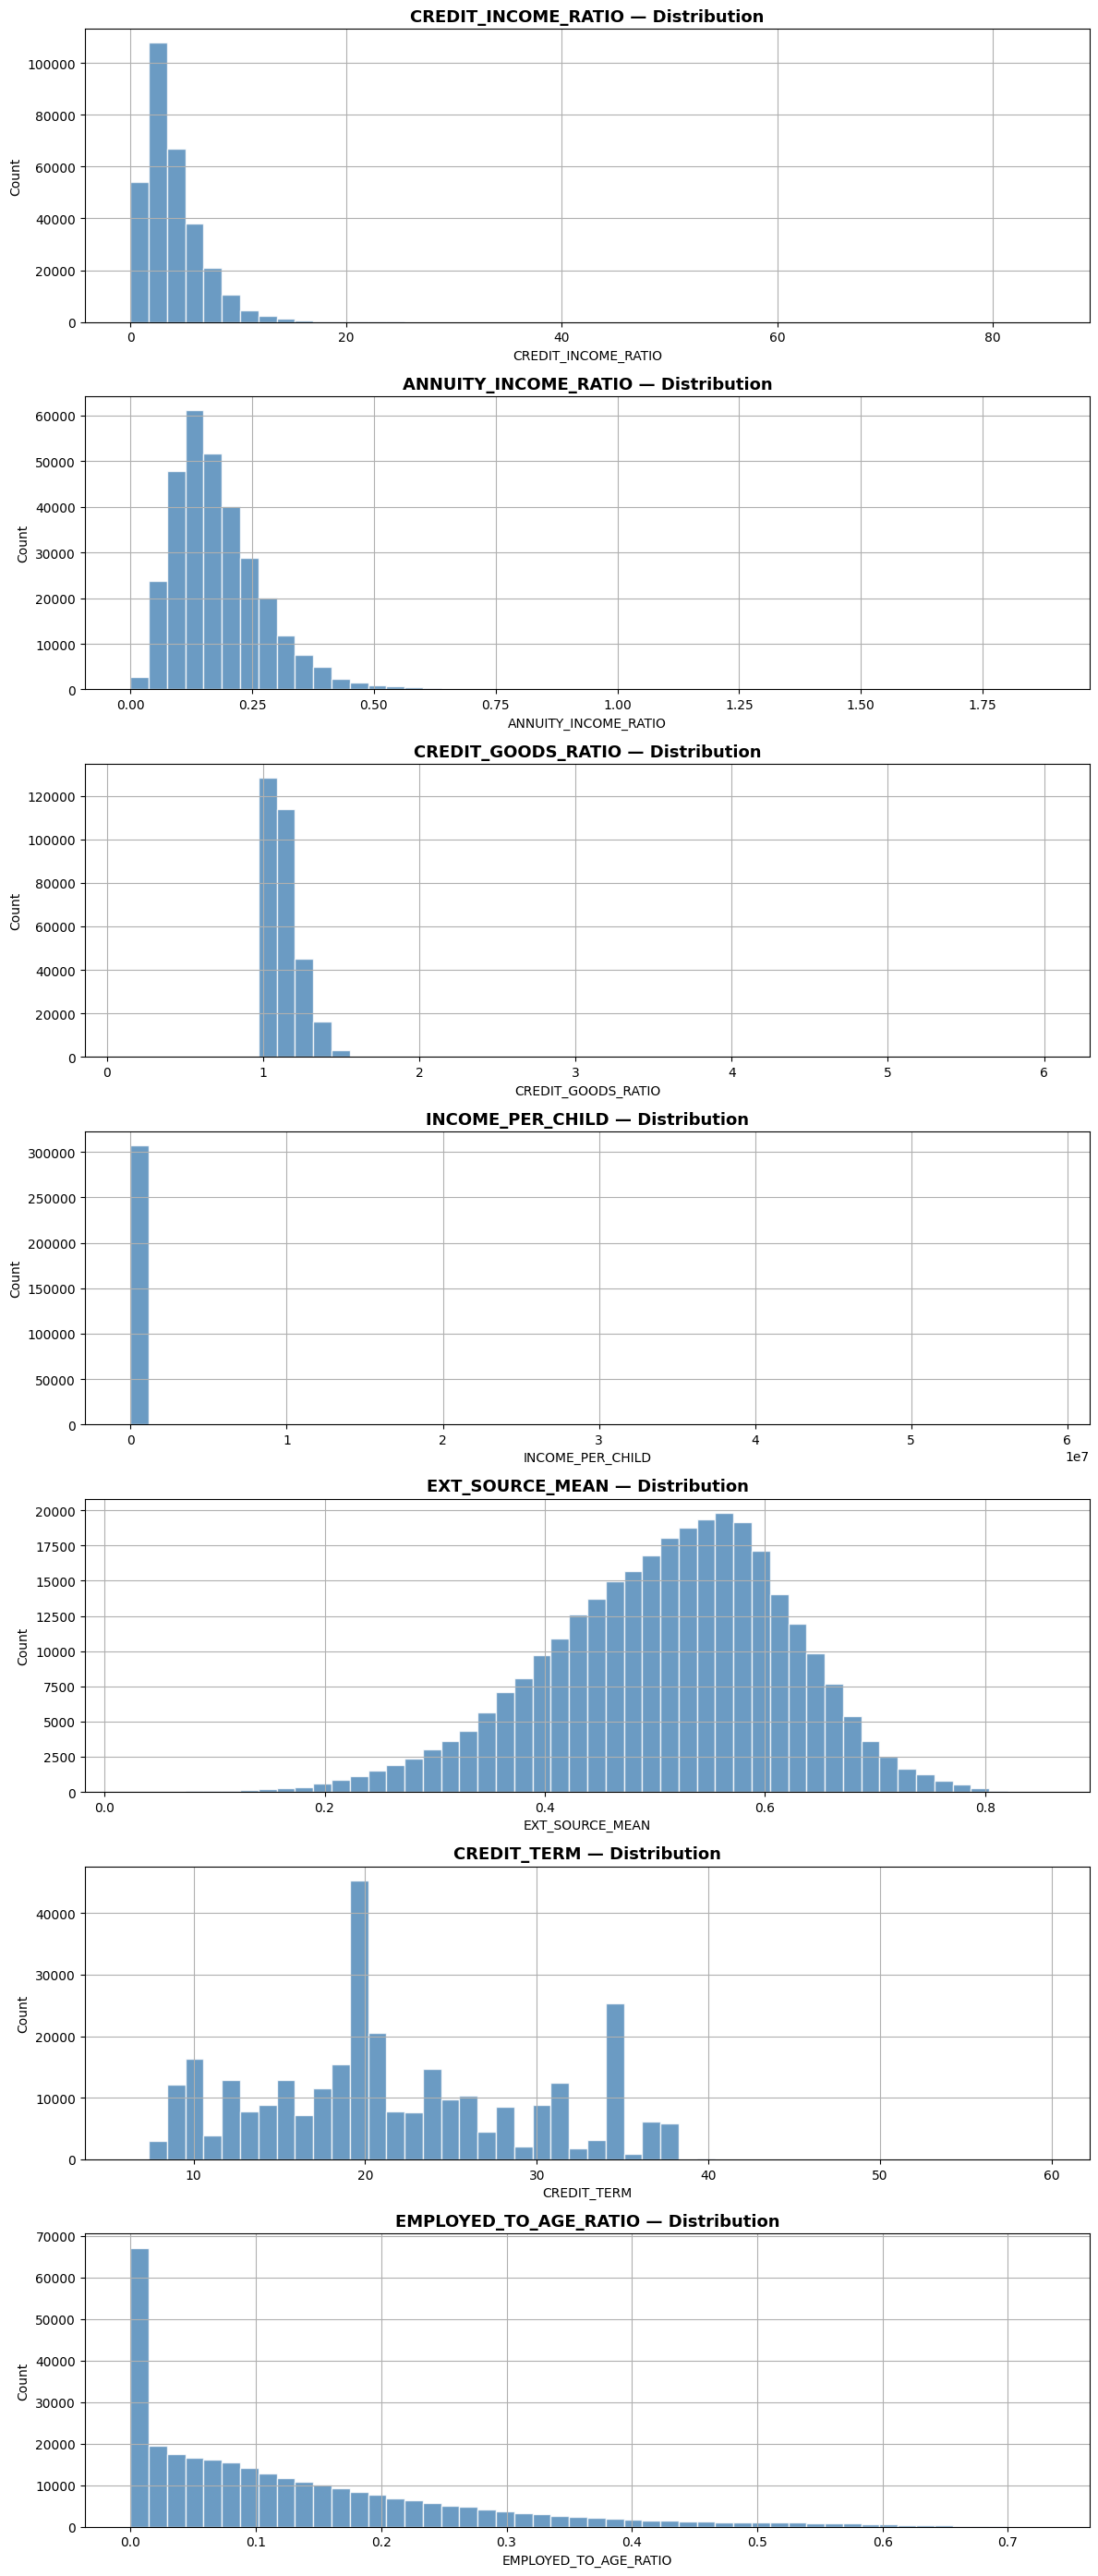

In [12]:
fig, axes = plt.subplots(len(new_features), 1, figsize=(12, 4 * len(new_features)))

for i, feat in enumerate(new_features):
    ax = axes[i]
    train[feat].hist(bins=50, ax=ax, color='steelblue', edgecolor='white', alpha=0.8)
    ax.set_title(f'{feat} — Distribution', fontsize=13, fontweight='bold')
    ax.set_xlabel(feat)
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

### 2.3 Correlation with TARGET

In [13]:
print('=== Correlation with TARGET ===')
for feat in new_features:
    corr = train[feat].corr(train['TARGET'])
    print(f'  {feat:<25} : {corr:+.4f}')

=== Correlation with TARGET ===
  CREDIT_INCOME_RATIO       : -0.0077
  ANNUITY_INCOME_RATIO      : +0.0143
  CREDIT_GOODS_RATIO        : +0.0685
  INCOME_PER_CHILD          : -0.0125
  EXT_SOURCE_MEAN           : -0.2208
  CREDIT_TERM               : -0.0321
  EMPLOYED_TO_AGE_RATIO     : -0.0363


---
## 3. Save Feature-Engineered Data

In [14]:
train.to_csv('train_fe.csv', index=False)
test.to_csv('test_fe.csv', index=False)

print('Feature-engineered data saved!')
print(f'  train_fe.csv : {train.shape}')
print(f'  test_fe.csv  : {test.shape}')

print(f'\nAll columns ({train.shape[1]}):')
for i, col in enumerate(train.columns, 1):
    print(f'  {i:>2}. {col}')

Feature-engineered data saved!
  train_fe.csv : (307511, 66)
  test_fe.csv  : (48744, 65)

All columns (66):
   1. SK_ID_CURR
   2. TARGET
   3. NAME_CONTRACT_TYPE
   4. CODE_GENDER
   5. FLAG_OWN_CAR
   6. FLAG_OWN_REALTY
   7. CNT_CHILDREN
   8. AMT_INCOME_TOTAL
   9. AMT_CREDIT
  10. AMT_ANNUITY
  11. AMT_GOODS_PRICE
  12. NAME_EDUCATION_TYPE
  13. EXT_SOURCE_1
  14. EXT_SOURCE_2
  15. EXT_SOURCE_3
  16. ORGANIZATION_TYPE
  17. AGE
  18. YEARS_EMPLOYED
  19. NAME_TYPE_SUITE_Family
  20. NAME_TYPE_SUITE_Group of people
  21. NAME_TYPE_SUITE_Other_A
  22. NAME_TYPE_SUITE_Other_B
  23. NAME_TYPE_SUITE_Spouse, partner
  24. NAME_TYPE_SUITE_Unaccompanied
  25. NAME_INCOME_TYPE_Commercial associate
  26. NAME_INCOME_TYPE_Maternity leave
  27. NAME_INCOME_TYPE_Pensioner
  28. NAME_INCOME_TYPE_State servant
  29. NAME_INCOME_TYPE_Student
  30. NAME_INCOME_TYPE_Unemployed
  31. NAME_INCOME_TYPE_Working
  32. NAME_FAMILY_STATUS_Married
  33. NAME_FAMILY_STATUS_Separated
  34. NAME_FAMILY_STAT